In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/data.csv')
df

,km,price
0,240000,3650
1,139800,3800
2,150500,4400
3,185530,4450
4,176000,5250
5,114800,5350
6,166800,5800
7,89000,5990
8,144500,5999
9,84000,6200


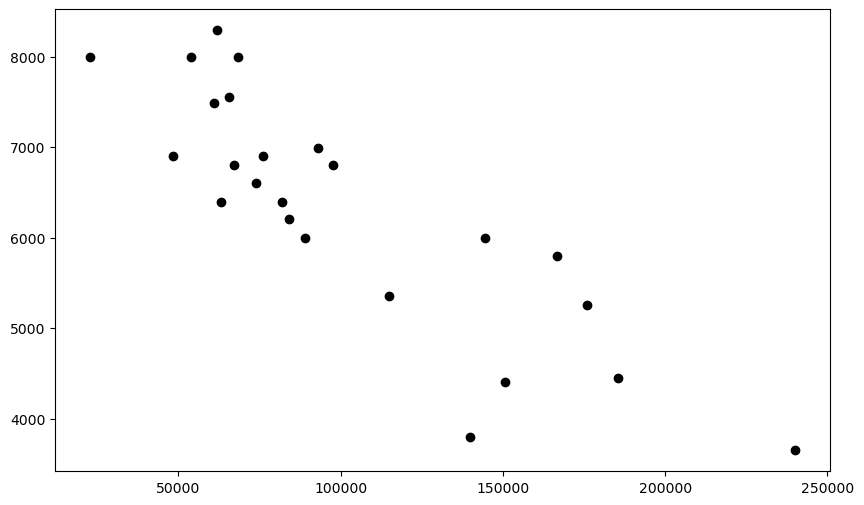

In [6]:
X = df['km']
Y = df['price']
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='black');

In [7]:
m = 0
c = 0

learning_r = 0.1
epochs = 1000

n = float(len(X))

# X_S = (X - np.mean(X)) / np.std(X)  # Standardization
# Y_S = (Y - np.mean(Y)) / np.std(Y)

X_S = (X - np.min(X)) / (np.max(X) - np.min(X))  # Min-Max Scaling
Y_S = (Y - np.min(Y)) / (np.max(Y) - np.min(Y))

for i in range(epochs):
    Y_preds = m * X_S + c

    D_c = (-2/n) * np.sum((Y_S - Y_preds))
    D_m = (-2/n) * np.sum(X_S * (Y_S - Y_preds))

    if i % 100 == 0:
        print(f"Iteration {i}: m={m:.5f}, c={c:.5f}, D_m={D_m:.5f}, D_c={D_c:.5f}")
    
    m -= learning_r * D_m
    c -= learning_r * D_c

print (f"end m = {m}, end c = {c}")

Iteration 0: m=0.00000, c=0.00000, D_m=-0.30297, D_c=-1.15596
Iteration 100: m=-0.56528, c=0.77327, D_m=0.04352, D_c=-0.01649
Iteration 200: m=-0.84198, c=0.87810, D_m=0.01604, D_c=-0.00608
Iteration 300: m=-0.94400, c=0.91675, D_m=0.00592, D_c=-0.00224
Iteration 400: m=-0.98161, c=0.93100, D_m=0.00218, D_c=-0.00083
Iteration 500: m=-0.99548, c=0.93625, D_m=0.00080, D_c=-0.00030
Iteration 600: m=-1.00059, c=0.93819, D_m=0.00030, D_c=-0.00011
Iteration 700: m=-1.00247, c=0.93890, D_m=0.00011, D_c=-0.00004
Iteration 800: m=-1.00317, c=0.93917, D_m=0.00004, D_c=-0.00002
Iteration 900: m=-1.00343, c=0.93926, D_m=0.00001, D_c=-0.00001
end m = -1.0035205786061452, end c = 0.9392980302239486


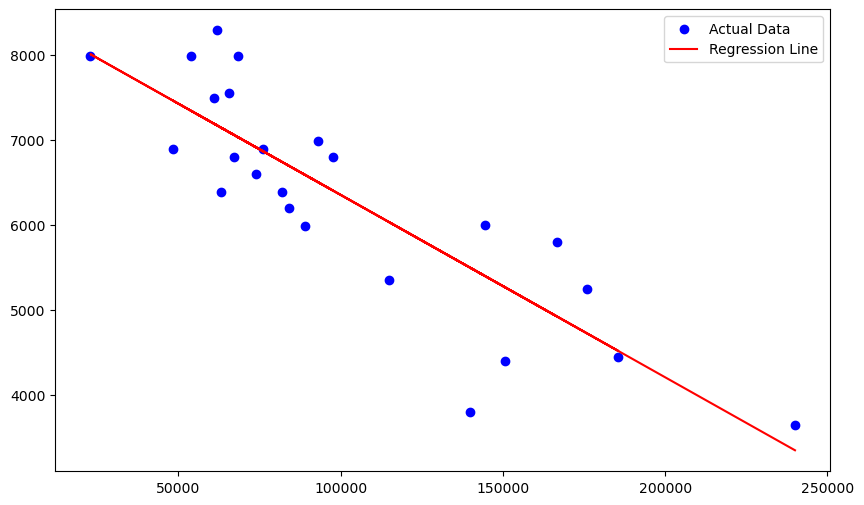

In [8]:
Y_preds = c + m * X_S

Y_preds_original = Y_preds * (Y.max() - Y.min()) + Y.min()


plt.figure(figsize=(10, 6))
plt.scatter(X, Y, label="Actual Data", color='blue')
plt.plot(X, Y_preds_original, label="Regression Line", color='red')
plt.legend()
plt.show()